## Why use a tile grid?

A geographic map gives large states more visual weight, even when area is not the variable of interest. A **tile grid map** gives every state the same-sized square, so categorical patterns are easier to compare. It is a useful alternative to the polygon maps in the [map section](/map).


## Libraries

This example uses [pandas](/pandas) to join the data to a state layout and [Matplotlib](/matplotlib) to draw and label the tiles. Only core Matplotlib patches are needed, so no geographic shape files or mapping packages are required.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle


## Dataset

The example uses a 50-state insurance licensing and continuing education course-availability snapshot published by [TSI National](https://tsinational.com/insurance-licensing-and-ce-requirements-by-state/). It records whether this **private training provider** listed course options in each state on July 20, 2026; it does not describe regulatory approval or the overall availability of insurance education in a state. The gallery copy keeps only the state code, state name, category, and review date needed to reproduce the chart.


In [2]:
# A local gallery copy makes the example reproducible.
path = "../../static/data/us-insurance-course-availability.csv"
data = pd.read_csv(path)

data["tsi_course_availability"].value_counts()


tsi_course_availability
course options available    44
not currently offered        6
Name: count, dtype: int64

## Build the state layout

Each tuple below contains a state code, column, and row. After merging the layout with the dataset, two assertions make the example fail loudly if a state is missing or duplicated.


In [3]:
tile_positions = [
    ("AK", 0, 0), ("ME", 10, 0),
    ("VT", 8, 1), ("NH", 9, 1),
    ("WA", 0, 2), ("ID", 1, 2), ("MT", 2, 2),
    ("ND", 3, 2), ("MN", 4, 2), ("WI", 5, 2),
    ("MI", 6, 2), ("NY", 7, 2), ("MA", 9, 2),
    ("RI", 10, 2),
    ("OR", 0, 3), ("NV", 1, 3), ("WY", 2, 3),
    ("SD", 3, 3), ("IA", 4, 3), ("IL", 5, 3),
    ("IN", 6, 3), ("OH", 7, 3), ("PA", 8, 3),
    ("NJ", 9, 3), ("CT", 10, 3),
    ("CA", 0, 4), ("UT", 1, 4), ("CO", 2, 4),
    ("NE", 3, 4), ("MO", 4, 4), ("KY", 5, 4),
    ("WV", 6, 4), ("VA", 7, 4), ("MD", 8, 4),
    ("DE", 9, 4),
    ("AZ", 1, 5), ("NM", 2, 5), ("KS", 3, 5),
    ("AR", 4, 5), ("TN", 5, 5), ("NC", 6, 5),
    ("SC", 7, 5),
    ("OK", 3, 6), ("LA", 4, 6), ("MS", 5, 6),
    ("AL", 6, 6), ("GA", 7, 6),
    ("HI", 0, 7), ("TX", 3, 7), ("FL", 8, 7),
]

layout = pd.DataFrame(
    tile_positions, columns=["state_code", "column", "row"]
)
plot_data = data.merge(layout, on="state_code", validate="one_to_one")

assert len(plot_data) == 50
assert plot_data["state_code"].is_unique


## Draw and encode the tiles

A `Rectangle` represents each state. A dictionary maps the two categories to colors, while a manually constructed legend keeps the labels independent of Matplotlib's drawing order.


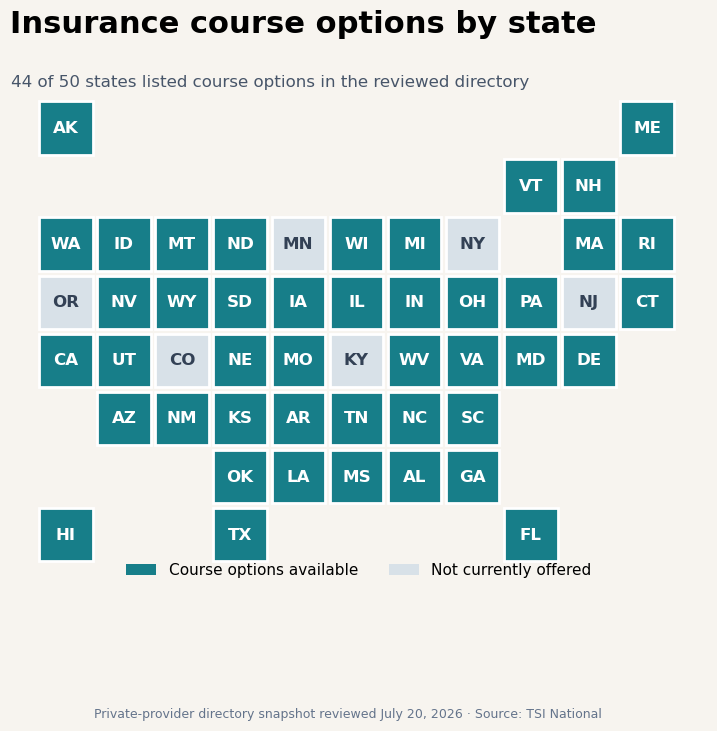

In [4]:
colors = {
    "course options available": "#177E89",
    "not currently offered": "#D8E1E8",
}
labels = {
    "course options available": "Course options available",
    "not currently offered": "Not currently offered",
}

fig, ax = plt.subplots(figsize=(9, 9), facecolor="#F7F4EF")
ax.set_facecolor("#F7F4EF")

for state in plot_data.itertuples():
    category = state.tsi_course_availability
    tile = Rectangle(
        (state.column, state.row),
        0.92,
        0.92,
        facecolor=colors[category],
        edgecolor="white",
        linewidth=2,
    )
    ax.add_patch(tile)
    ax.text(
        state.column + 0.46,
        state.row + 0.46,
        state.state_code,
        ha="center",
        va="center",
        color="white" if category == "course options available" else "#334155",
        fontsize=12,
        fontweight="bold",
    )

available = (
    plot_data["tsi_course_availability"] == "course options available"
).sum()
legend_handles = [
    Patch(facecolor=colors[key], edgecolor="none", label=labels[key])
    for key in colors
]

ax.set_xlim(-0.5, 11.5)
ax.set_ylim(8.35, -0.75)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "Insurance course options by state",
    loc="left",
    fontsize=22,
    fontweight="bold",
    pad=18,
)
ax.text(
    -0.48,
    -0.25,
    f"{available} of 50 states listed course options in the reviewed directory",
    fontsize=12,
    color="#475569",
)
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
    frameon=False,
    fontsize=11,
)
fig.text(
    0.5,
    0.055,
    "Private-provider directory snapshot reviewed July 20, 2026 · Source: TSI National",
    ha="center",
    fontsize=9,
    color="#64748B",
)

plt.show()


## Going further

The same layout can encode a numeric variable with a sequential color scale, or show change over time with small multiples. For polygon-based alternatives, see the gallery's [choropleth maps](/choropleth) and [hexbin maps](/hexbin).
